<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Liverpool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

#Liverpool

In [ ]:
#Obtener datos
df = yf.download('LIVEPOL1.MX', start='2024-01-01')

/tmp/ipykernel_914/1046451472.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('LIVEPOL1.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie de tiempo

##Medias Móviles

###Media Móvil Simple

In [ ]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

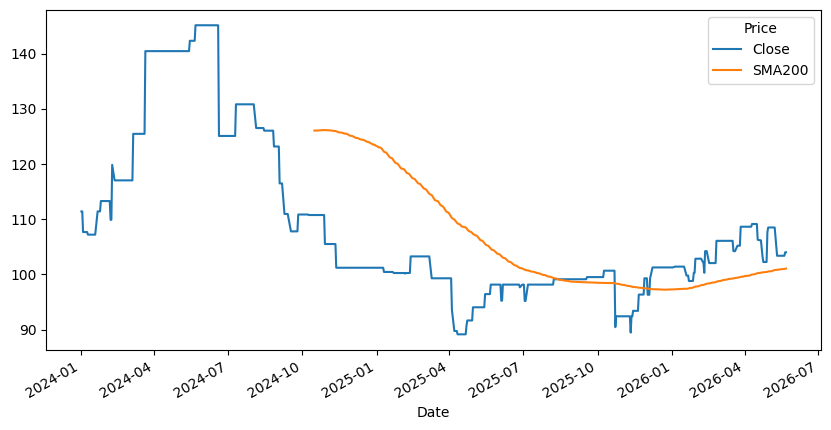

In [ ]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [ ]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [ ]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

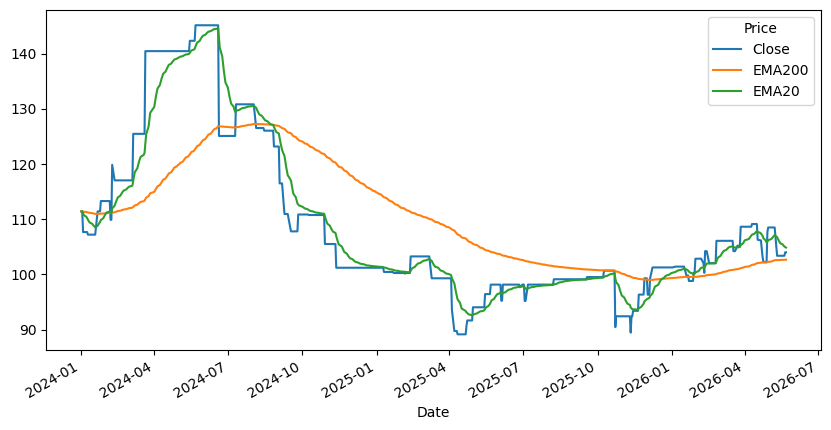

In [ ]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

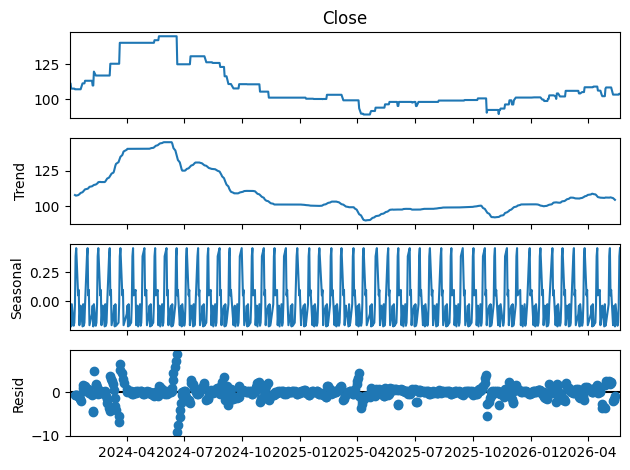

In [ ]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()


###Modelo Multiplicativo

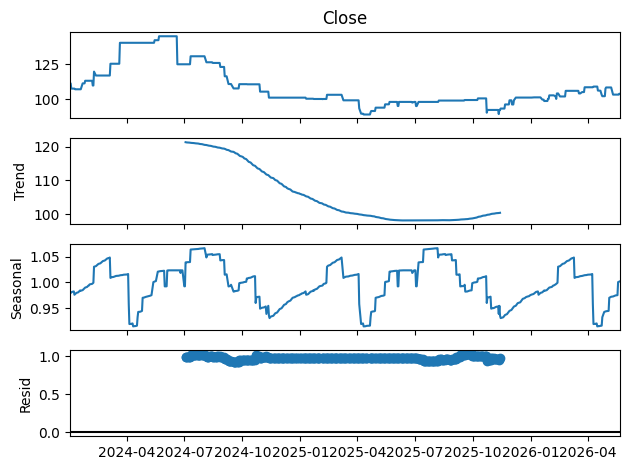

In [ ]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()


#Volatilidad

##Desviación Estándar

In [ ]:
#Obtener datos
precios = df['Close']
print(precios)

Date
2024-01-02    111.416779
2024-01-03    111.416779
2024-01-04    107.671684
2024-01-05    107.671684
2024-01-08    107.671684
                 ...    
2026-05-18    103.380005
2026-05-19    103.380005
2026-05-20    103.380005
2026-05-21    104.010002
2026-05-22    104.010002
Name: Close, Length: 597, dtype: float64


In [ ]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
                ...   
2026-05-18    0.000000
2026-05-19    0.000000
2026-05-20    0.000000
2026-05-21    0.006076
2026-05-22    0.000000
Name: Rendimientos_Log, Length: 597, dtype: float64


In [ ]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-05-18    0.000000
2026-05-19    0.000000
2026-05-20    0.000000
2026-05-21    0.006076
2026-05-22    0.000000
Name: Rendimientos_Log, Length: 596, dtype: float64


In [ ]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100

In [ ]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [ ]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0137 = 1.3731 %
Volatilidad anualizada: 0.2180 = 21.7975 %


##Average True Range (ATR)

In [ ]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [ ]:
print(high_low)

Date
2024-01-03    0.0
2024-01-04    0.0
2024-01-05    0.0
2024-01-08    0.0
2024-01-09    0.0
             ... 
2026-05-18    0.0
2026-05-19    0.0
2026-05-20    0.0
2026-05-21    0.0
2026-05-22    0.0
Length: 596, dtype: float64


In [ ]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    3.745094
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-05-18    0.000000
2026-05-19    0.000000
2026-05-20    0.000000
2026-05-21    0.629997
2026-05-22    0.000000
Length: 596, dtype: float64


In [ ]:
print(low_close)

Date
2024-01-03         NaN
2024-01-04    3.745094
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-05-18    0.000000
2026-05-19    0.000000
2026-05-20    0.000000
2026-05-21    0.629997
2026-05-22    0.000000
Length: 596, dtype: float64


In [ ]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [ ]:
print(true_range)

Date
2024-01-03    0.000000
2024-01-04    3.745094
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-05-18    0.000000
2026-05-19    0.000000
2026-05-20    0.000000
2026-05-21    0.629997
2026-05-22    0.000000
Length: 596, dtype: float64


In [ ]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [ ]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [ ]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-05-18  103.380005  103.380005  103.380005       0.726938
2026-05-19  103.380005  103.380005  103.380005       0.675014
2026-05-20  103.380005  103.380005  103.380005       0.626799
2026-05-21  104.010002  104.010002  104.010002       0.627027
2026-05-22  104.010002  104.010002  104.010002       0.582240


In [ ]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 0.4223


In [ ]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 6.7033


#Parámetros (p,d,q) de ARIMA

##Precios Diferenciados

###Serie Estacionaria


In [ ]:
#Obtener datos
precios = df['Close']

In [ ]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [ ]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: -1.3026
Valor p: 0.6280
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.6279795773468498)

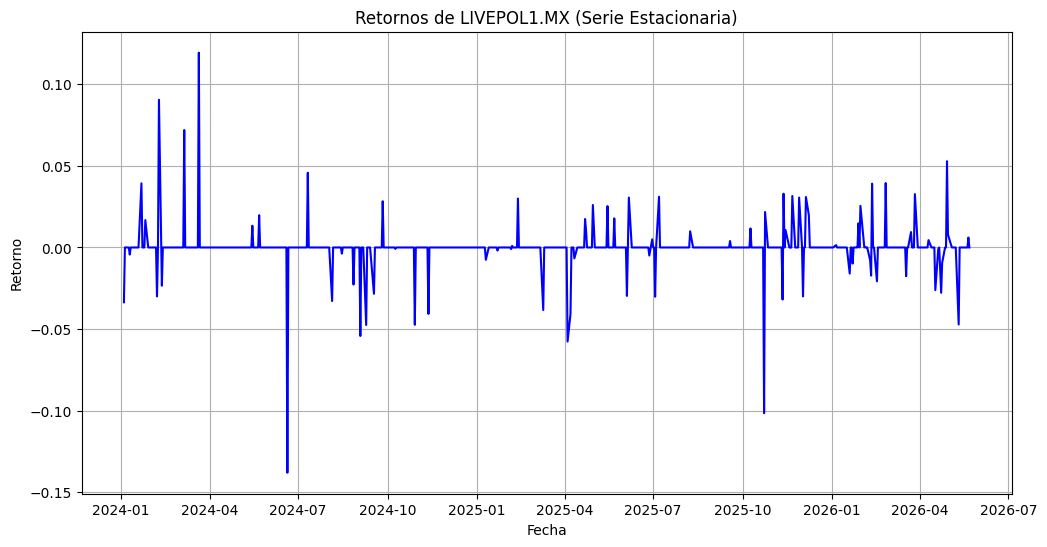

In [ ]:
# Visualización
plt.figure(figsize=(12, 6))
plt.plot(retornos, label=f'Retornos de {'LIVEPOL1.MX'}', color='blue')
plt.title(f'Retornos de {'LIVEPOL1.MX'} (Serie Estacionaria)')
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.grid(True)
plt.show()

####Diferenciando para hacer estacionaria la serie

In [ ]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = df['Close'].diff().dropna()

In [ ]:
# Mostrar los primeros elementos de la serie diferenciada
print("Head of the differenced price series:")
print(differenced_prices.head())

Head of the differenced price series:
Date
2024-01-04   -3.745094
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
2024-01-10   -0.468140
Name: Close, dtype: float64


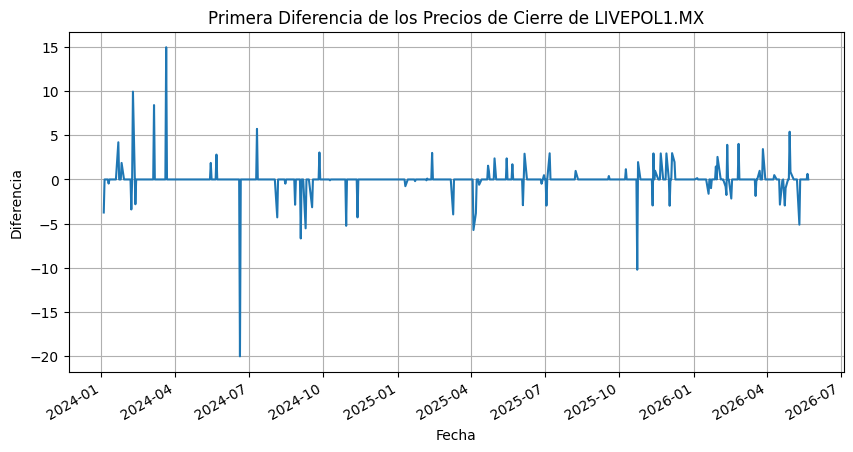

In [ ]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"LIVEPOL1.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [ ]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -24.8649
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

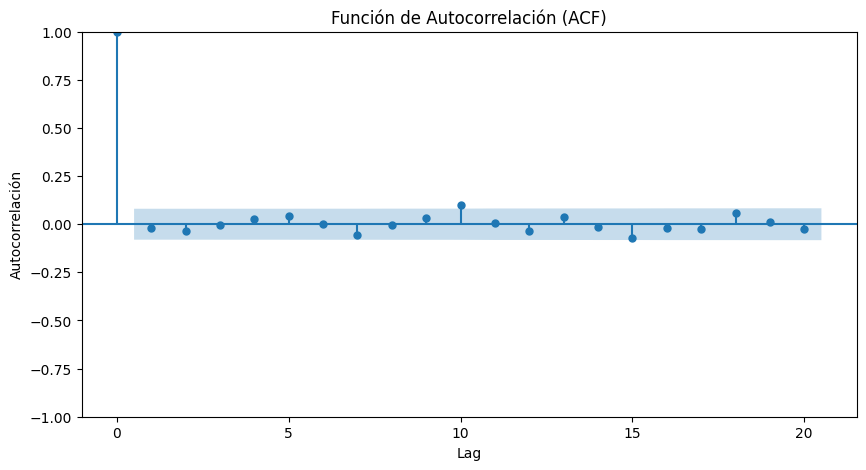

In [ ]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(differenced_prices, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial (PACF)

<Figure size 1000x500 with 0 Axes>

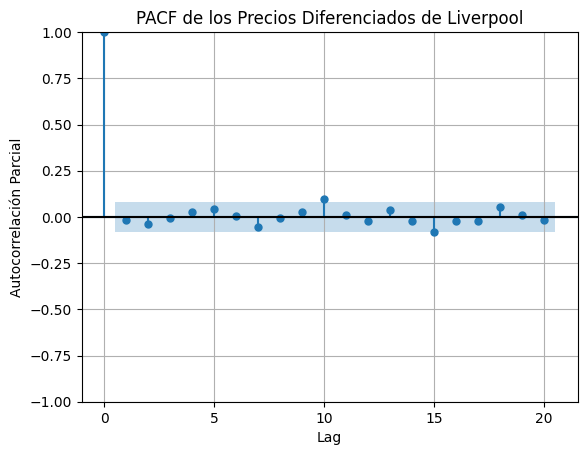

In [ ]:
#Graficar la PACF
plt.figure(figsize=(10, 5))
plot_pacf(differenced_prices, lags=20, method='ywm') # method='ywm' es Yule-Walker modificado
plt.title('PACF de los Precios Diferenciados de Liverpool')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')
plt.axhline(y=0, color='k', linestyle='-')
plt.grid(True)
plt.show()

##Rendimientos Logarítmicos

In [ ]:
#Cargar datos y calcular rendimientos logarítmicos
df['log_Close'] = np.log(df['Close'])

In [ ]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['log_Close'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -1.3184
Valor p: 0.6207
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.6207004849906974)

###Estacionariedad

In [ ]:
df['rendimiento_log'] = df['log_Close'].diff().dropna()

In [ ]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['rendimiento_log'], "Retornos Logarítmicos Diferenciados")


--- Prueba ADF para: Retornos Logarítmicos Diferenciados ---
Estadístico de Dickey-Fuller: -24.9022
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

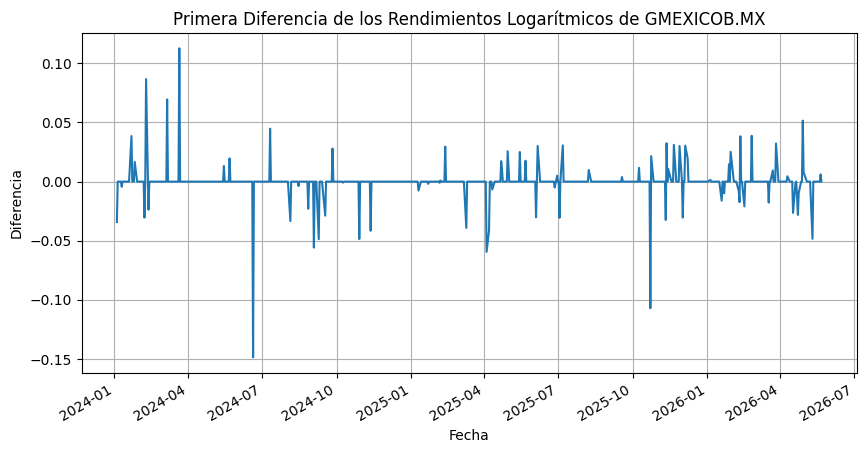

In [ ]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
df['rendimiento_log'].plot()
plt.title(f'Primera Diferencia de los Rendimientos Logarítmicos de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

###Función de Autocorrelación

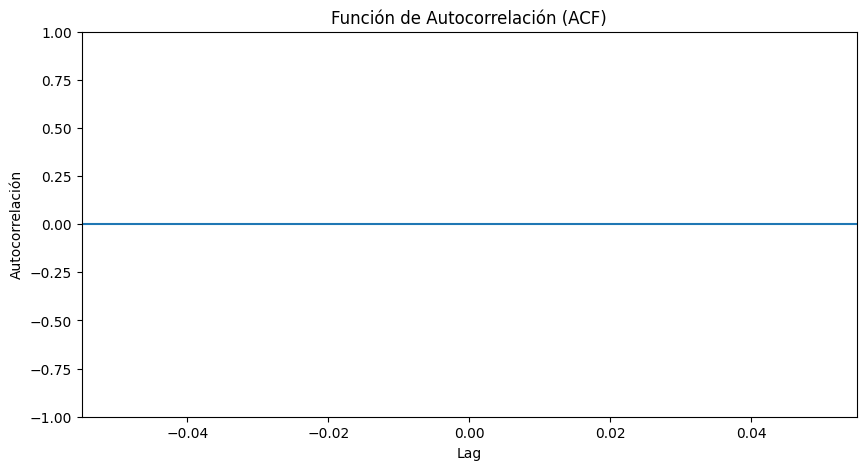

In [ ]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

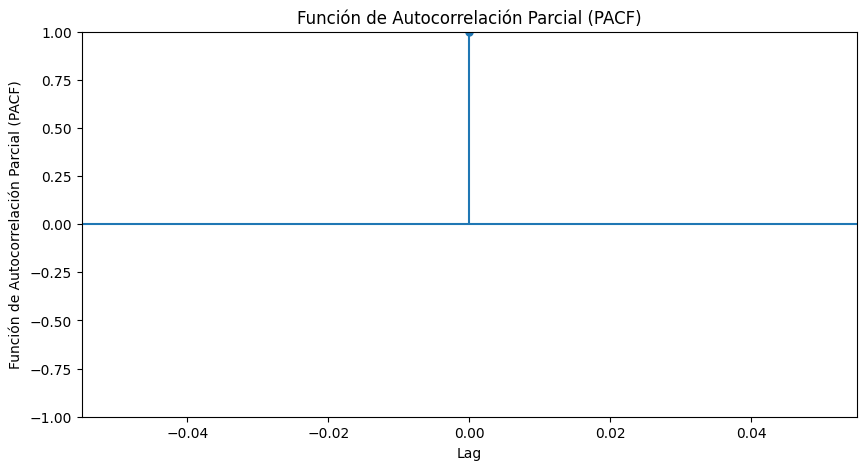

In [ ]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()